# **Exercício 4 - Regras de associação e Mineração de Texto**

Aluno: Fabio Kishino

### **Parte 1 – Regra de Associação** 🔗
* Realize os seguintes passos:
1. Utilize alguma implementação do Apriori, por exemplo, a da biblioteca mlxtend (python) ou do
pacote Arules (R).
2. Utilize os dados sobre compras de supermercado “supermercado.csv”, disponível no moodle.
3. Garanta que um conjunto de itens não contenha dois itens iguais.
4. Execute o Apriori com as configurações: suporte mínimo = 0.001 e confiança = 0.25.
5. Gere regras que contenham no consequente somente itens do tipo "bottled beer".
6. Avaliação: o que você encontrou de interessante? Faça uma breve análise das regras e resultados encontrados.

In [41]:
# Importação das bibliotecas
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt


In [53]:
# Lendo o arquivo de transações
transactions_supermarket = []

with open('../../data-sets/supermercado.csv', 'r', encoding='utf-8') as file:
    for line in file:
        items = line.strip().split(',')
        transactions_supermarket.append(items)
    
print(type(transactions_supermarket))
print(len(transactions_supermarket))

<class 'list'>
9835


In [54]:
# Garantir que um conjunto de itens não contenha dois itens iguais
transactions = []
for i in range(len(transactions_supermarket)):
    transaction = list(set(transactions_supermarket[i]))
    transactions.append(transaction)

transactions


[['ready soups', 'semi-finished bread', 'margarine', 'citrus fruit'],
 ['yogurt', 'coffee', 'tropical fruit'],
 ['whole milk'],
 ['yogurt', 'cream cheese ', 'pip fruit', 'meat spreads'],
 ['whole milk',
  'condensed milk',
  'other vegetables',
  'long life bakery product'],
 ['yogurt', 'whole milk', 'abrasive cleaner', 'rice', 'butter'],
 ['rolls/buns'],
 ['rolls/buns',
  'UHT-milk',
  'liquor (appetizer)',
  'bottled beer',
  'other vegetables'],
 ['pot plants'],
 ['whole milk', 'cereals'],
 ['white bread',
  'chocolate',
  'bottled water',
  'tropical fruit',
  'other vegetables'],
 ['curd',
  'yogurt',
  'whole milk',
  'dishes',
  'bottled water',
  'citrus fruit',
  'tropical fruit',
  'butter',
  'flour'],
 ['beef'],
 ['frankfurter', 'soda', 'rolls/buns'],
 ['tropical fruit', 'chicken'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter milk

In [55]:
# Transformar os dados em uma matriz binária
te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(encoded, columns=te.columns_)
df_encoded

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9833,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [56]:
# Executar o Apriori com as configurações: suporte mínimo = 0.001 e confiança = 0.25.
frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True)
print(frequent_itemsets.to_string())

        support                                                                                     itemsets
0      0.008033                                                                      (Instant food products)
1      0.033452                                                                                   (UHT-milk)
2      0.003559                                                                           (abrasive cleaner)
3      0.003254                                                                           (artif. sweetener)
4      0.017692                                                                              (baking powder)
5      0.002745                                                                           (bathroom cleaner)
6      0.052466                                                                                       (beef)
7      0.033249                                                                                    (berries)
8      0.026029    

In [57]:
# Regras com o valor de confiança mínimo escolhido (0.25)
dfRegras= association_rules(frequent_itemsets, metric='confidence', min_threshold=0.25)

dfRegras['antecedents'] = dfRegras['antecedents'].apply(lambda x: ', '.join(list(x))).astype("unicode")
dfRegras['consequents'] = dfRegras['consequents'].apply(lambda x: ', '.join(list(x))).astype("unicode")

dfRegras

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,Instant food products,hamburger meat,0.008033,0.033249,0.003050,0.379747,11.421438,1.0,0.002783,1.558640,0.919834,0.079787,0.358415,0.235745
1,Instant food products,other vegetables,0.008033,0.193493,0.002745,0.341772,1.766332,1.0,0.001191,1.225271,0.437368,0.013811,0.183854,0.177980
2,Instant food products,rolls/buns,0.008033,0.183935,0.002339,0.291139,1.582838,1.0,0.000861,1.151235,0.371205,0.012332,0.131367,0.151927
3,Instant food products,whole milk,0.008033,0.255516,0.003050,0.379747,1.486196,1.0,0.000998,1.200291,0.329790,0.011710,0.166868,0.195842
4,abrasive cleaner,other vegetables,0.003559,0.193493,0.001627,0.457143,2.362585,1.0,0.000938,1.485671,0.578795,0.008325,0.326904,0.232775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19389,"whipped/sour cream, yogurt, other vegetables, ...","whole milk, tropical fruit",0.003457,0.042298,0.001118,0.323529,7.648826,1.0,0.000972,1.415734,0.872276,0.025057,0.293652,0.174986
19390,"whipped/sour cream, yogurt, other vegetables, ...","whole milk, root vegetables",0.003559,0.048907,0.001118,0.314286,6.426195,1.0,0.000944,1.387011,0.847403,0.021782,0.279025,0.168577
19391,"whipped/sour cream, whole milk, root vegetable...","yogurt, other vegetables",0.002745,0.043416,0.001118,0.407407,9.383728,1.0,0.000999,1.614235,0.895892,0.024831,0.380511,0.216584
19392,"whipped/sour cream, whole milk, other vegetabl...","yogurt, root vegetables",0.004474,0.025826,0.001118,0.250000,9.680118,1.0,0.001003,1.298898,0.900725,0.038328,0.230117,0.146654


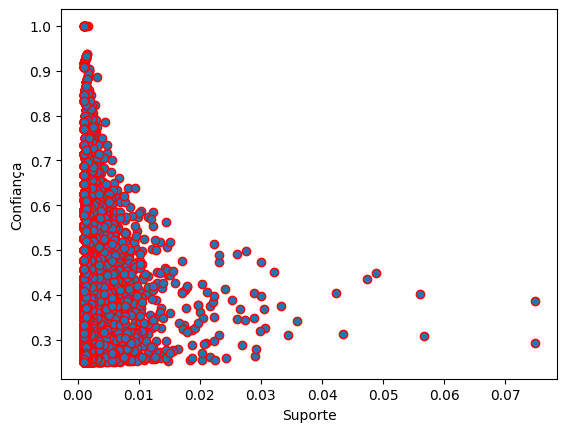

In [58]:
# Scatter plot da confiança e suporte. Auxilia no entendimento do espaço de regras

plt.scatter(data = dfRegras, x='support', y='confidence', edgecolors='red')
plt.xlabel('Suporte')
plt.ylabel('Confiança')
plt.show()

In [59]:
# Filtrar apenas 'bottled beer' no consequente
dfRegras_bottled_beer = dfRegras[dfRegras['consequents'].str.contains('bottled beer')]
dfRegras_bottled_beer

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
27,liquor,bottled beer,0.011083,0.080529,0.004677,0.422018,5.240594,1.0,0.003785,1.590831,0.818250,0.053801,0.371398,0.240050
28,red/blush wine,bottled beer,0.019217,0.080529,0.004881,0.253968,3.153760,1.0,0.003333,1.232483,0.696299,0.051447,0.188630,0.157287
29,tea,bottled beer,0.003864,0.080529,0.001118,0.289474,3.594664,1.0,0.000807,1.294071,0.724610,0.013431,0.227245,0.151681
1016,"bottled water, herbs",bottled beer,0.003050,0.080529,0.001220,0.400000,4.967172,1.0,0.000974,1.532452,0.801122,0.014815,0.347451,0.207576
1021,"bottled water, oil",bottled beer,0.004169,0.080529,0.001220,0.292683,3.634516,1.0,0.000884,1.299942,0.727895,0.014616,0.230735,0.153917
1030,"bottled water, sugar",bottled beer,0.004779,0.080529,0.001220,0.255319,3.170535,1.0,0.000835,1.234719,0.687883,0.014510,0.190099,0.135235
1041,"butter, onions",bottled beer,0.004067,0.080529,0.001017,0.250000,3.104482,1.0,0.000689,1.225962,0.680653,0.012165,0.184314,0.131313
1103,"liquor, red/blush wine",bottled beer,0.002135,0.080529,0.001932,0.904762,11.235269,1.0,0.001760,9.654448,0.912944,0.023929,0.896421,0.464376
1107,"liquor, soda",bottled beer,0.002135,0.080529,0.001220,0.571429,7.095960,1.0,0.001048,2.145433,0.860913,0.014981,0.533894,0.293290
1127,"red/blush wine, other vegetables",bottled beer,0.004982,0.080529,0.001525,0.306122,3.801407,1.0,0.001124,1.325120,0.740629,0.018160,0.245352,0.162531


#### **Breve análise - Parte 1**

A análise revela que existe uma relação inversa entre confiança e quantidade de regras: quanto maior a confiança exigida, menor o número de regras encontradas.

As regras na última etapa apresentam valores de lift superiores a 1, indicando forte associação entre os produtos. Os maiores valores de lift demonstram que a compra de licor ou vinho aumenta significativamente a probabilidade de compra de cerveja.

O baixo suporte das regras (entre 0,0015 e 0,0059) mostra que essas associações, embora fortes, ocorrem em uma pequena parcela das transações, caracterizando um padrão de compra específico de determinados consumidores. 



## **Parte 2 – Mineração de texto** ⛏️
#### Use o dataset "tweets_trump.csv", que contém todos os tweets do D. Trump e faça o que é pedido abaixo.

1. Utilizando o texto dos tweets identifique 5 tópicos latentes com o LDA, com um
preprocessamento básico -- remoção de urls, remoção de pontuação, stemming e conversão para
minúsculo.
2. Avalie os tópicos encontrados. Algum preprocessamento a mais poderia ser útil para a produção
de um melhor resultado?

In [ ]:
import re
import nltk
import spacy
import string
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary

from nltk.stem.porter import PorterStemmer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fabiokishino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/fabiokishino/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/fabiokishino/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
df = pd.read_csv('../../data-sets/tweets_trump.csv', header=0, sep=',')
dfTweetsTrump = df['text']
dfTweetsTrump

0        Republicans and Democrats have both created ou...
1        I was thrilled to be back in the Great city of...
2        RT @CBS_Herridge: READ: Letter to surveillance...
3        The Unsolicited Mail In Ballot Scam is a major...
4        RT @MZHemingway: Very friendly telling of even...
                               ...                        
56566    RT @RandPaul: I don’t know why @JoeBiden think...
56567    RT @EliseStefanik: President @realDonaldTrump ...
56568    RT @TeamTrump: LIVE: Presidential Debate #Deba...
56569    Just signed an order to support the workers of...
56570    Suburban women want Safety &amp; Security. Joe...
Name: text, Length: 56571, dtype: object

### **Preprocessamento**

In [ ]:
stemmer = PorterStemmer()

# Remover URLs, pontuação, stemming e convertendo para minúsculas
def preprocess_tweet(tweet):  
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)

    # Remove pontuação
    tweet = tweet.translate(str.maketrans('', '', string.punctuation))
    
    # Converte para minúsculas
    tweet = tweet.lower()
    
    # Aplica stemming
    words = tweet.split()
    tweet = " ".join([stemmer.stem(word) for word in words])
    
    return tweet

# Aplicar o preprocessamento em todos os tweets
tweets_preprocessed = dfTweetsTrump.apply(preprocess_tweet)

# Drop tweets vazios após o preprocessamento
tweets_preprocessed = tweets_preprocessed[tweets_preprocessed.str.strip() != ''].reset_index(drop=True)

tweets_preprocessed

0        republican and democrat have both creat our ec...
1        i wa thrill to be back in the great citi of ch...
2        rt cbsherridg read letter to surveil court obt...
3        the unsolicit mail in ballot scam is a major t...
4        rt mzhemingway veri friendli tell of event her...
                               ...                        
55263    rt randpaul i don’t know whi joebiden think he...
55264    rt elisestefanik presid realdonaldtrump excel ...
55265    rt teamtrump live presidenti debat debates2020...
55266    just sign an order to support the worker of de...
55267    suburban women want safeti amp secur joe biden...
Name: text, Length: 55268, dtype: object

In [ ]:
dataset_prep = [d.split() for d in tweets_preprocessed]
dictionary_prep = Dictionary(dataset_prep)
corpus_prep = [dictionary_prep.doc2bow(doc) for doc in dataset_prep]

model_prep =LdaModel(corpus=corpus_prep, id2word=dictionary_prep, num_topics=5, iterations=100, passes=5, random_state=1)


In [ ]:
for i in  model_prep.show_topics(num_topics=5, num_words=10, log=False):
    print(i)
    print('---')


(0, '0.054*"the" + 0.025*"and" + 0.024*"to" + 0.022*"a" + 0.021*"is" + 0.018*"of" + 0.014*"that" + 0.012*"they" + 0.009*"in" + 0.009*"i"')
---
(1, '0.052*"you" + 0.026*"thank" + 0.026*"to" + 0.023*"realdonaldtrump" + 0.022*"i" + 0.022*"for" + 0.020*"great" + 0.020*"the" + 0.017*"a" + 0.017*"and"')
---
(2, '0.063*"the" + 0.033*"to" + 0.031*"of" + 0.027*"in" + 0.026*"and" + 0.015*"a" + 0.014*"our" + 0.013*"for" + 0.012*"we" + 0.011*"is"')
---
(3, '0.146*"rt" + 0.052*"realdonaldtrump" + 0.025*"presid" + 0.023*"trump" + 0.010*"russian" + 0.008*"negoti" + 0.008*"potu" + 0.007*"gopchairwoman" + 0.006*"stock" + 0.006*"page"')
---
(4, '0.041*"on" + 0.030*"at" + 0.029*"trump" + 0.019*"be" + 0.016*"will" + 0.016*"donald" + 0.016*"great" + 0.013*"foxandfriend" + 0.013*"my" + 0.013*"tonight"')
---


#### **Breve análise - Parte 2**

Aplicar a remoção de stop-words durante a fase de pré-processamento pode influenciar positivamente os resultados, já que grande parte dos tópicos identificados contém esse tipo de palavra, o que dificulta a compreensão efetiva do assunto.